In [ ]:
#Business understanding
#here we know that we want to find prediction (MPG)-->Output know-->supervised-->continuous-->linear regression

In [119]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")
car_dataset=pd.read_csv(r"C:\Users\Lenovo\OneDrive\Documents\Cars.csv")
car_dataset

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [ ]:
# data understanding
car_dataset.shape

In [ ]:
car_dataset.isna().sum()

In [84]:
car_dataset.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [85]:
car_dataset.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


In [86]:
#Check assumption for linear regression

### Test 1 : Linear test

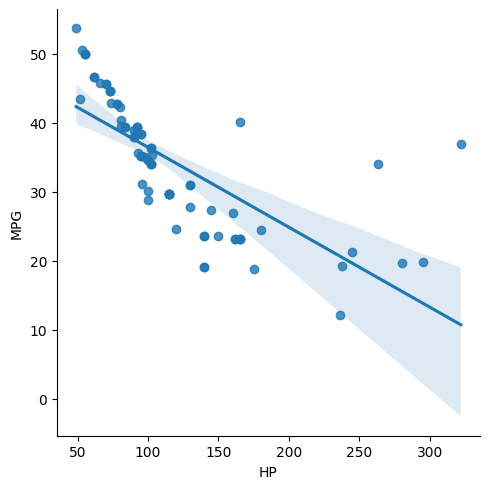

In [87]:
# use lmplot for linear test
sns.lmplot(data=car_dataset, x="HP",y="MPG")

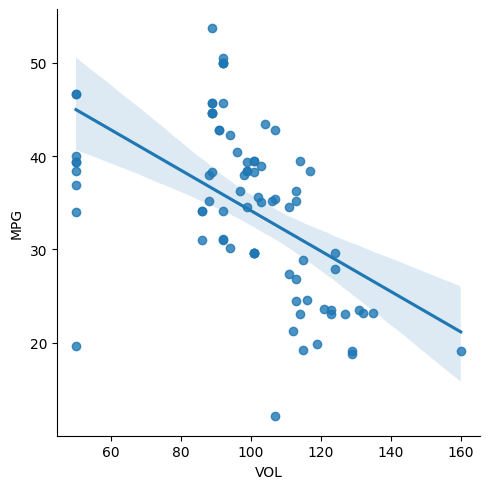

In [88]:
sns.lmplot(data=car_dataset, x="VOL",y="MPG")

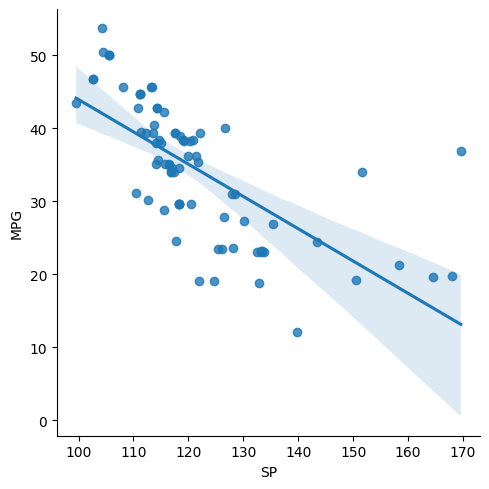

In [89]:
sns.lmplot(data=car_dataset, x="SP",y="MPG")

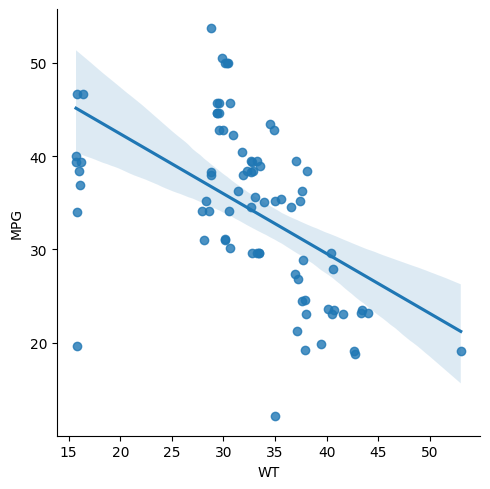

In [90]:
sns.lmplot(data=car_dataset, x="WT",y="MPG")

In [91]:
#linear test fail because datapoints are not nearest to other datapoints

#### Test 1 Linear test failed

### Test 2 Normality test

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

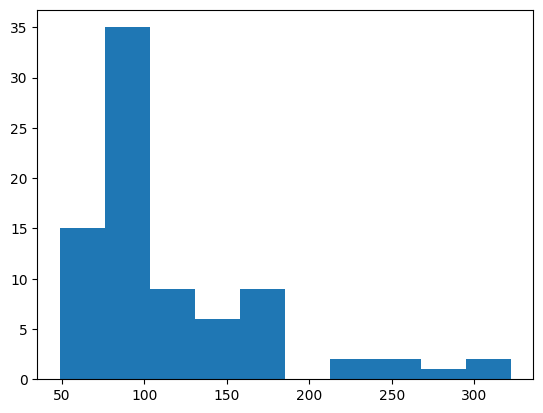

In [92]:
plt.hist(car_dataset["HP"])

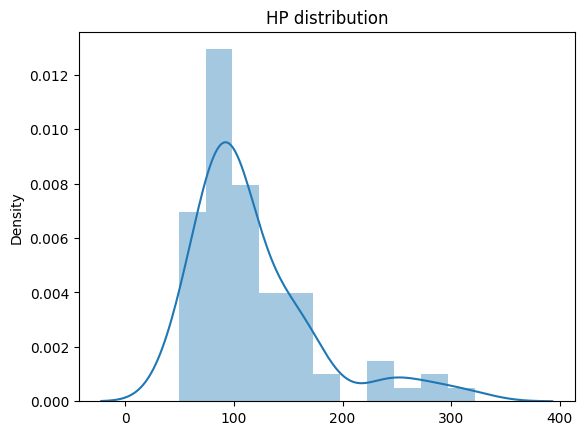

In [93]:
sns.distplot(x=car_dataset["HP"])
plt.title("HP distribution")
plt.show()

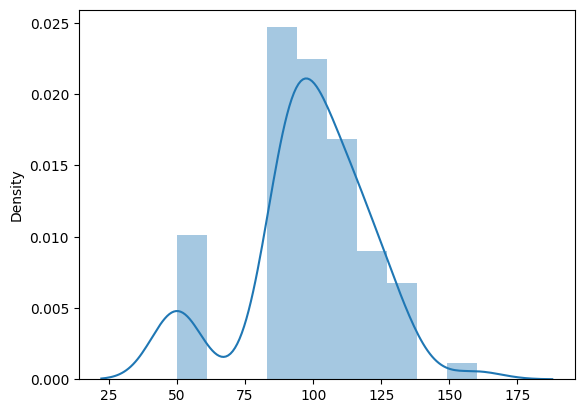

In [94]:
sns.distplot(x=car_dataset["VOL"])
plt.show()

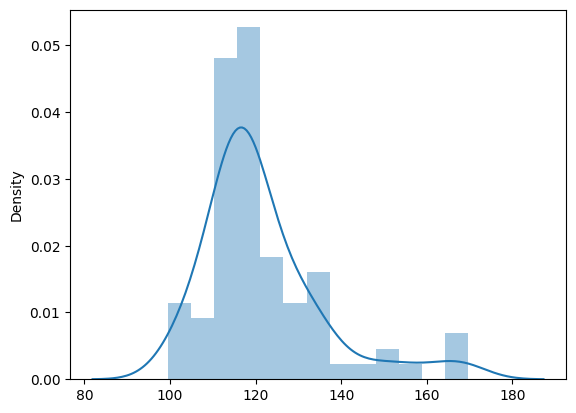

In [95]:
sns.distplot(x=car_dataset["SP"])
plt.show()

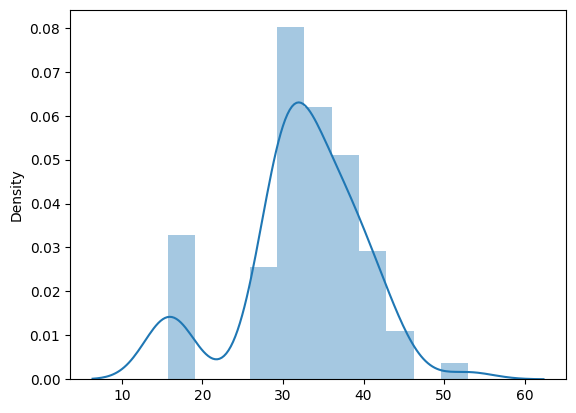

In [96]:
sns.distplot(x=car_dataset["WT"])
plt.show()

#### Test 2 Normality test also failed

### Test 3 - Multicollinearity test

In [97]:
car_dataset.corr()

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


In [98]:
#high colleration is not good for linear regression (HP & SP is high colleration is not good)- multi collinearity

In [99]:
corr_matrix=car_dataset.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


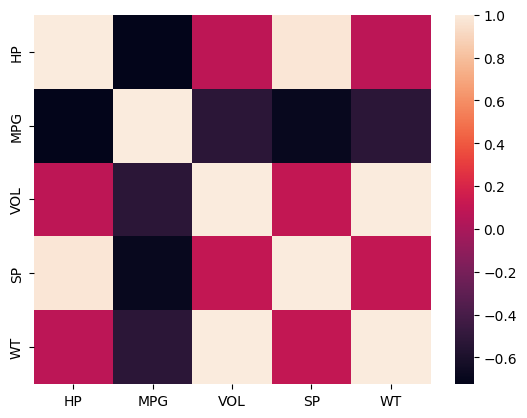

In [100]:
sns.heatmap(data=corr_matrix)
plt.show()

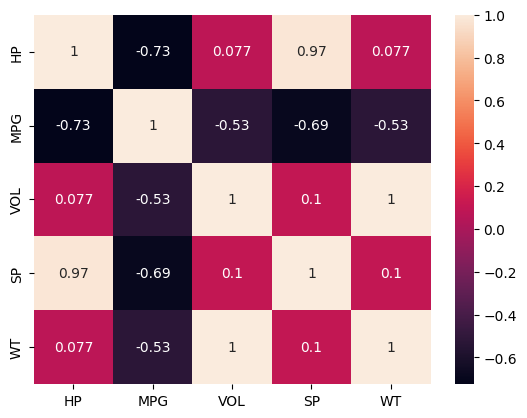

In [101]:
sns.heatmap(data=corr_matrix,annot=True)
plt.show()

In [102]:
# There is multicollinearity in this data

### Test 4: Autoregression test

In [103]:
#here autoregression test , bcoz input features dont have time based in linear regression.
#so ,NO time based.
#so autoregression PASSED.

### Test 5 and 6 :

In [104]:
#Can be done only after model is built,trained and tested.

### 4. Data preparation

In [105]:
car_dataset

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [106]:
### There is nothing to prepare, because all features are numeric.

In [114]:
X=car_dataset[["HP","VOL","SP","WT"]]
X

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [115]:
y=car_dataset["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

## 5. Model Building

In [120]:
linear_model= LinearRegression()

## 6.Model Training

In [121]:
linear_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [122]:
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

In [123]:
linear_model.intercept_

np.float64(30.67733585215165)

In [126]:
linear_model.coef_

array([-0.20544372, -0.33605084,  0.39562692,  0.40057409])

## 7. Model Testing

In [129]:
y_pred=linear_model.predict(X)

## 8.Model Evaluation

In [130]:
error=y-y_pred
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

In [131]:
car_dataset["error"]=error
car_dataset

,HP,MPG,VOL,SP,WT,error
0,49,53.700681,89,104.185353,28.762059,10.258747
1,55,50.013401,92,105.461264,30.466833,7.624608
2,55,50.013401,92,105.461264,30.193597,7.734060
3,70,45.696322,92,113.461264,30.632114,3.157963
4,53,50.504232,92,104.461264,29.889149,8.331584
...,...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947,15.617904
77,238,19.197888,115,150.576579,37.923113,1.298838
78,263,34.000000,50,151.598513,15.769625,7.863547
79,295,19.833733,119,167.944460,39.423099,7.517122


#### Test 5 : Homoscedasticity test

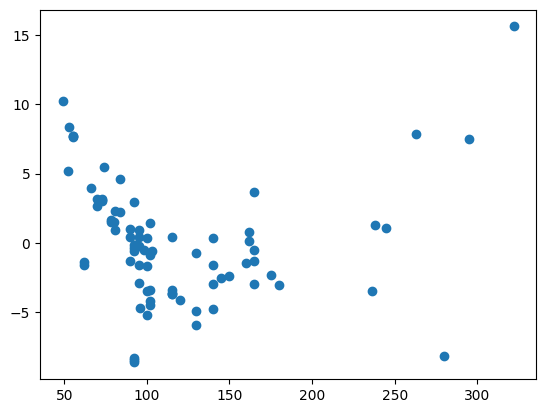

In [133]:
plt.scatter(data=car_dataset,x="HP",y="error")
plt.show()

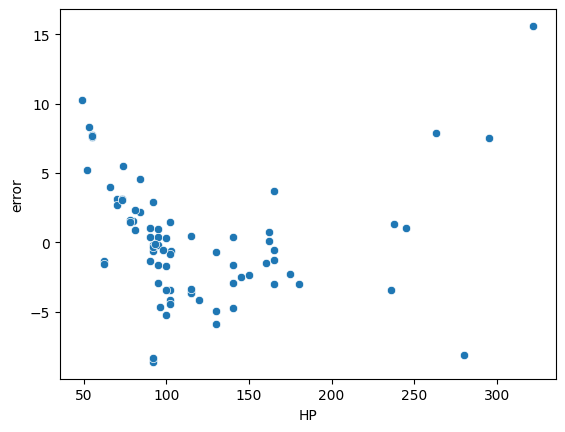

In [135]:
sns.scatterplot(data=car_dataset,x="HP",y="error")
plt.show()

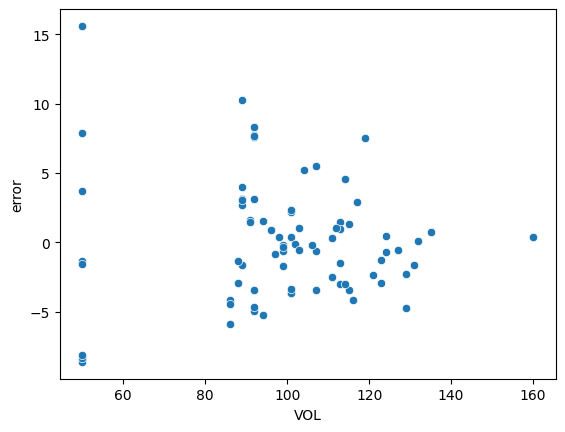

In [136]:
sns.scatterplot(data=car_dataset,x="VOL",y="error")
plt.show()

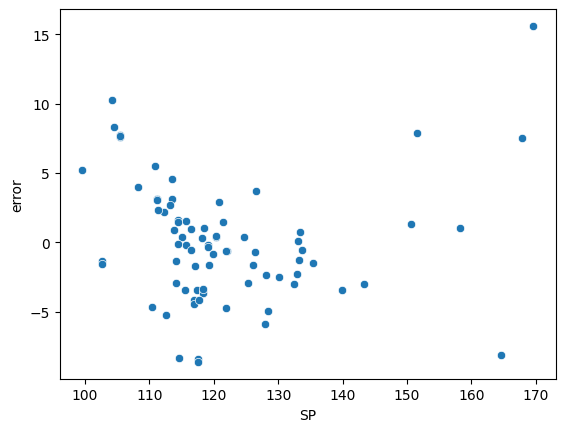

In [137]:
sns.scatterplot(data=car_dataset,x="SP",y="error")
plt.show()

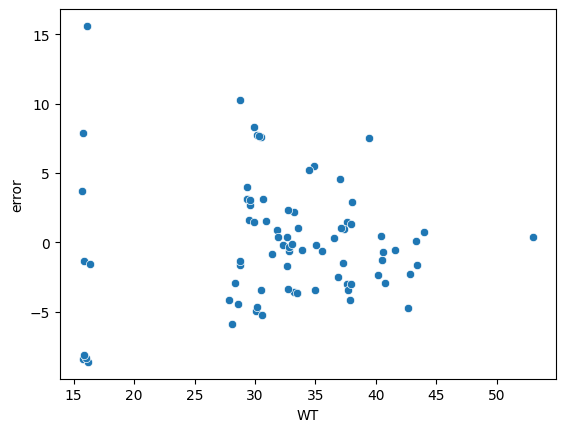

In [138]:
sns.scatterplot(data=car_dataset,x="WT",y="error")
plt.show()

In [139]:
# so, homoscedasticity test also failed

### Test 6: Zero residual mean test 

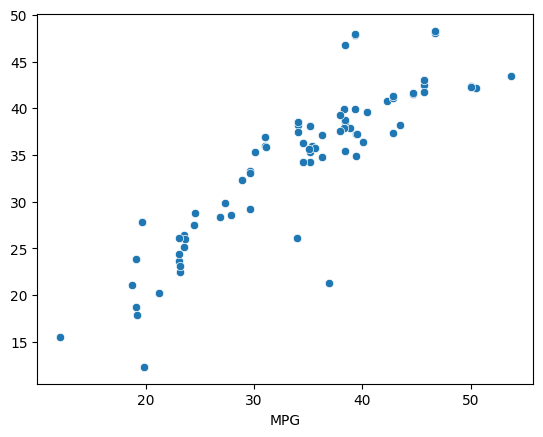

In [140]:
sns.scatterplot(x=car_dataset["MPG"],y=y_pred)
plt.show()

In [ ]:
# so zero residual mean test also failed

### 9. Model Deployement

In [142]:
from pickle import dump
dump(obj=linear_model,file=open(file="linear_intelligence_file.pkl",mode="wb"))

In [143]:
from pickle import load
linear_intel_pkl=load(file=open(file="linear_intelligence_file.pkl",mode="rb"))
linear_intel_pkl

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [144]:
linear_intel_pkl.predict(X)

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

### --------------------------THE END------------------